# Go Game Review Analyser

Date: `2026-03-25`

Author: `@sthornewillve`

This notebook is the prototype that takes go games analysed and creates a database from them in order to analyse.

___

# Setup Notebook

In [1]:
import os
import json
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

from openai import OpenAI
from pprint import pprint
from go_game_analyser_helperfuncs import analyse_game_review_summary, analyse_tags

In [2]:
# Create OpenAI Connection
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Import prompts
with open("prompt_configs.json") as f:
    prompts = json.load(f)

In [3]:
# Get game review summaries
conn = sqlite3.connect("game_reviews.db")
game_review_df = pd.read_sql("SELECT * FROM reviews", conn)
game_review_df.head()

,date,opponents_name,server,game_link,result,played_as,handicap,time_setting,review_notes,key_mistake,key_mistake_cause,positive_point,game_tags
0,2026-03-27,yuki22,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,0,20 + 5x30s,\n* End of game notes\n\t* Black managed to ki...,Wedge loses advantage,misplayed wedge,Created a large area,Created moyo; Lived with surrounded group; Ko ...
1,2026-03-27,qp1029,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,1,20m + 5x30s,\n* End of game notes\n\t* White resigns too e...,Resigned too early,Didn't count score before resigning,Managed a large kill and top-side territory,Resigned too early; Didn't count score; Create...
2,2026-03-24,dienfoonwu,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+R,White,3,20m + 5x30s,\n* End of game notes\n\t* Got surrounded and ...,Allowed atari leading to surround,Mishandled atari leading to surrounding,Exploited opponent's weak shape,Lived with surrounded group; Played weak shape...
3,2026-03-26,xiaoqiang2026,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+9.5,White,1,20m + 5x30s,\n* End of game notes\n\t* Both players manage...,Lost an immense group,misread life; allowed surround,Invaded Black's corner,Made bad shape; Died with surrounded group; Ga...
4,2026-03-26,noldoran,OGS,https://ai-sensei.com/game/VGIPT5au1Jg6jxQRo6P...,B+2.5,White,1,10m + 10s/mv,\n* End of game notes\n\t* Moyo game\n\t* Fair...,Missed endgame move E1,Missed endgame tesuji,Pressing Black down to make a moyo,Created moyo; Missed tesuji; Played solid game


___

# Analyse Games

In [4]:
summary = analyse_game_review_summary(game_review_df, client, prompts)

pprint(summary)

{'did_well': 'Shows strong strategic vision by consistently building large '
             'moyo and pressuring weak shapes, with several games '
             'transitioning into favorable endgames and clear point gains '
             'through calculated attacks.',
 'needs_work': 'Improve life-and-death reading and endgame accuracy to prevent '
               'losing big groups or missing kills, refine decision-making '
               '(e.g., when to resign or not to), and tighten shape management '
               'to avoid over-attachments and misreads in local fights (e.g., '
               'atari, ko, shimari attachments).'}


In [5]:
df_tag_counts = analyse_tags(game_review_df)

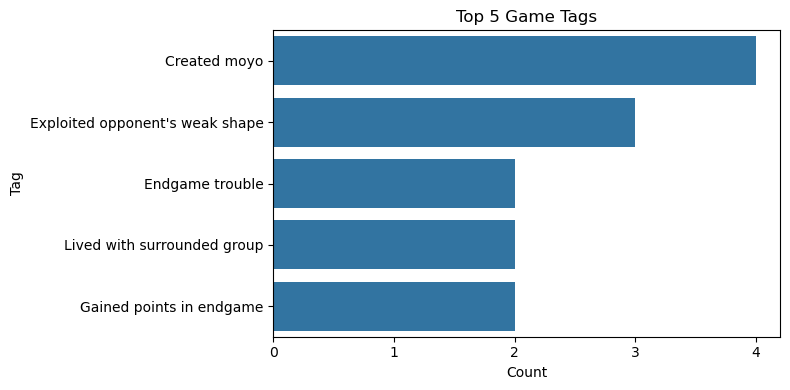

In [6]:
# Visualise Tags
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_tag_counts.sort_values(by='count', ascending=False).head(5), x='count', y='tag', ax=ax)
ax.set(title="Top 5 Game Tags", xlabel="Count", ylabel="Tag")
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
plt.tight_layout()
plt.show()
